# Exploratory Data Analysis

## 1. Dataset Overview

Exploratory Data Analysis (EDA) is the process of understanding the structure, quality, and characteristics of a dataset before performing data preprocessing and model building.

In this step, we will get a high-level understanding of the dataset by examining:

- Number of observations and features
- Column names
- Data types
- Sample records
- Basic structure of the dataset

This helps us understand what kind of data we are working with before performing deeper analysis.

In [1]:
import pandas as pd
import os
import ast
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/raw/ptbxl"

database_path = os.path.join(
    DATA_PATH,
    "ptbxl_database.csv"
)

scp_path = os.path.join(
    DATA_PATH,
    "scp_statements.csv"
)

df = pd.read_csv(database_path)
scp_df = pd.read_csv(scp_path)

print("Database shape:", df.shape)
print("SCP shape:", scp_df.shape)

Database shape: (21799, 28)
SCP shape: (71, 13)


### 1.1 Dataset Shape

First, we examine the number of rows and columns in the dataset.

The number of rows represents the number of observations, while the number of columns represents the variables available for each observation.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 21799
Number of columns: 28


### 1.2 Column Names

Next, we inspect all the column names available in the dataset.

This helps us understand the different types of information recorded for each ECG and provides an initial idea of how the dataset can be divided into patient information, recording information, diagnostic information, and other metadata.

In [3]:
df.columns.tolist()

['ecg_id',
 'patient_id',
 'age',
 'sex',
 'height',
 'weight',
 'nurse',
 'site',
 'device',
 'recording_date',
 'report',
 'scp_codes',
 'heart_axis',
 'infarction_stadium1',
 'infarction_stadium2',
 'validated_by',
 'second_opinion',
 'initial_autogenerated_report',
 'validated_by_human',
 'baseline_drift',
 'static_noise',
 'burst_noise',
 'electrodes_problems',
 'extra_beats',
 'pacemaker',
 'strat_fold',
 'filename_lr',
 'filename_hr']

### Observation

The dataset contains 28 variables associated with ECG recordings.

The variables can be broadly grouped into:

- **Identification:** `ecg_id`, `patient_id`
- **Patient demographics:** `age`, `sex`, `height`, `weight`
- **Recording metadata:** `nurse`, `site`, `device`, `recording_date`
- **Diagnostic information:** `report`, `scp_codes`, `heart_axis`, `infarction_stadium1`, `infarction_stadium2`
- **Validation information:** `validated_by`, `second_opinion`, `initial_autogenerated_report`, `validated_by_human`
- **ECG signal annotations:** `baseline_drift`, `static_noise`, `burst_noise`, `electrodes_problems`, `extra_beats`, `pacemaker`
- **Dataset organization:** `strat_fold`
- **ECG signal file references:** `filename_lr`, `filename_hr`

This initial grouping shows that the dataset contains not only patient-related information but also diagnostic, recording, validation, and ECG signal-related metadata.

### 1.3 Inspecting Sample Records

After examining the dataset structure and column names, we inspect a few actual observations using the first few rows of the dataset.

This helps us understand how the variables are represented in practice and allows us to identify potential data-quality issues, categorical values, missing values, and the structure of textual or diagnostic fields.

In [4]:
df.head(2)

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


## 2. Data Type Analysis

In this step, we examine the data type of each variable in the dataset.

Understanding data types is important because different types of variables require different exploratory analysis and preprocessing techniques.

For example, numerical variables can be analyzed using statistical measures such as mean and standard deviation, while categorical variables require frequency-based analysis. Date and text variables may require specialized processing.

In [5]:
df.dtypes

ecg_id                            int64
patient_id                      float64
age                             float64
sex                               int64
height                          float64
weight                          float64
nurse                           float64
site                            float64
device                           object
recording_date                   object
report                           object
scp_codes                        object
heart_axis                       object
infarction_stadium1              object
infarction_stadium2              object
validated_by                    float64
second_opinion                     bool
initial_autogenerated_report       bool
validated_by_human                 bool
baseline_drift                   object
static_noise                     object
burst_noise                      object
electrodes_problems              object
extra_beats                      object
pacemaker                        object


### Observation

The dataset contains a mixture of numerical, categorical/text, and boolean variables.

The variables are currently stored as:

- **Integer:** `ecg_id`, `sex`, `strat_fold`
- **Float:** `patient_id`, `age`, `height`, `weight`, `nurse`, `site`, `validated_by`
- **Object:** `device`, `recording_date`, `report`, `scp_codes`, `heart_axis`, `infarction_stadium1`, `infarction_stadium2`, and ECG annotation/file-reference columns
- **Boolean:** `second_opinion`, `initial_autogenerated_report`, `validated_by_human`

Some variables require further semantic investigation. For example, `nurse`, `site`, and `validated_by` are stored as numerical values but may represent categorical codes rather than continuous numerical measurements. Similarly, `recording_date` is stored as an object and may need to be treated as a datetime variable.

Therefore, the pandas data type alone should not be used to determine how a variable will be analyzed or processed.

## 3. Missing Value Analysis

Missing values are common in real-world datasets and can occur because information was not recorded, was unavailable, or was not applicable.

In this step, we will identify:

- Which variables contain missing values
- How many values are missing
- What percentage of each variable is missing

This will help us understand the completeness of the dataset before deciding how missing values should be handled during preprocessing.

In [6]:
df.isnull().sum()

ecg_id                              0
patient_id                          0
age                                 0
sex                                 0
height                          14825
weight                          12378
nurse                            1473
site                               17
device                              0
recording_date                      0
report                              0
scp_codes                           0
heart_axis                       8468
infarction_stadium1             16187
infarction_stadium2             21696
validated_by                     9378
second_opinion                      0
initial_autogenerated_report        0
validated_by_human                  0
baseline_drift                  20201
static_noise                    18539
burst_noise                     21186
electrodes_problems             21769
extra_beats                     19850
pacemaker                       21508
strat_fold                          0
filename_lr 

### 3.2 Percentage of Missing Values

The number of missing values alone does not provide enough context.

For example, 10,000 missing values may be very large for a dataset containing 12,000 observations but relatively smaller for a dataset containing 100,000 observations.

Therefore, we calculate the percentage of missing values relative to the total number of observations.

In [7]:
missing_percentage = (df.isnull().sum() / len(df) * 100)
missing_percentage.sort_values(ascending=False)

electrodes_problems             99.862379
infarction_stadium2             99.527501
pacemaker                       98.665076
burst_noise                     97.187944
baseline_drift                  92.669389
extra_beats                     91.059223
static_noise                    85.045186
infarction_stadium1             74.255700
height                          68.007707
weight                          56.782421
validated_by                    43.020322
heart_axis                      38.845819
nurse                            6.757191
site                             0.077985
recording_date                   0.000000
device                           0.000000
ecg_id                           0.000000
patient_id                       0.000000
age                              0.000000
sex                              0.000000
scp_codes                        0.000000
report                           0.000000
second_opinion                   0.000000
initial_autogenerated_report     0

### Observation

The missing-value analysis shows that the completeness of the variables varies substantially across the dataset.

Several ECG annotation variables have extremely high levels of missingness. For example, `electrodes_problems` has approximately 99.86% missing values, `infarction_stadium2` has approximately 99.53%, and `pacemaker` has approximately 98.67% missing values.

Other variables such as `height`, `weight`, `infarction_stadium1`, `validated_by`, and `heart_axis` also contain substantial amounts of missing information.

In contrast, important variables such as `ecg_id`, `patient_id`, `age`, `sex`, `device`, `recording_date`, `report`, and `scp_codes` have no missing values.

The high missingness observed in several ECG annotation variables suggests that these variables may represent optional annotations rather than universally recorded measurements. Therefore, missing values should not be automatically treated as errors.

Further investigation is required before deciding whether these variables should be retained, transformed, or removed during preprocessing.

### 3.3 Visualizing Missing Values

To better understand the extent of missing data across variables, we visualize the percentage of missing values.

A bar chart allows us to quickly compare the completeness of different variables and identify variables with particularly high levels of missingness.

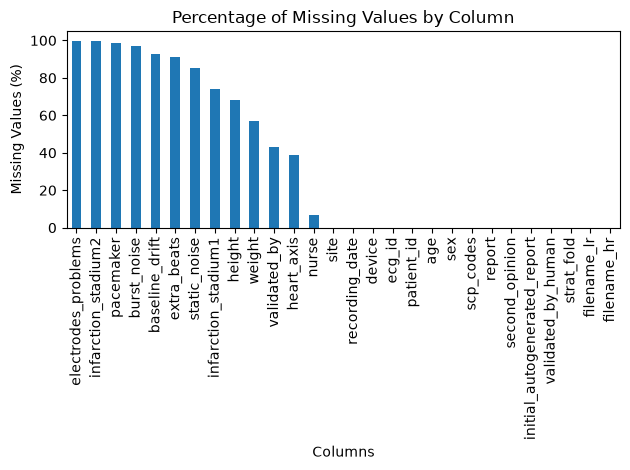

In [8]:
import matplotlib.pyplot as plt
missing_percentage_sorted = missing_percentage.sort_values(ascending=False)

plt.Figure(figsize=(12,6))

missing_percentage_sorted.plot(kind='bar')

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


### Observation

The visualization confirms that missing values are highly concentrated in a small number of variables.

The ECG annotation variables such as `electrodes_problems`, `infarction_stadium2`, `pacemaker`, `burst_noise`, `baseline_drift`, `extra_beats`, and `static_noise` have extremely high missingness.

Variables such as `height`, `weight`, `infarction_stadium1`, `validated_by`, and `heart_axis` also show substantial missingness.

On the other hand, most of the core identification, demographic, recording, and diagnostic variables have little or no missing data.

This indicates that missingness is not uniformly distributed across the dataset. It is concentrated in specific groups of variables, which suggests that these fields may represent optional or condition-specific annotations rather than information expected for every ECG recording.

Therefore, missing-value treatment should be performed based on the meaning and role of each variable rather than applying a single rule to all columns.

### 3.4 Distinguishing Missing Values from "Unknown"

Missing values and explicit categories such as `"unknown"` can represent different situations.

A missing value (`NaN`) generally indicates that no value was recorded, whereas `"unknown"` is an explicitly recorded category indicating that the information was not known or could not be determined.

We therefore examine the frequency of `"unknown"` separately from actual missing values.

In [9]:
df['infarction_stadium1'].value_counts(dropna=False)

infarction_stadium1
NaN               16187
unknown            3430
Stadium III         980
Stadium II-III      943
Stadium I           166
Stadium II           88
Stadium I-II          5
Name: count, dtype: int64

### Observation

The `infarction_stadium1` variable contains three distinct types of values: missing values (`NaN`), the explicit category `"unknown"`, and specific infarction stages.

Out of 21,799 ECG recordings, 16,187 records have missing values, while 3,430 records explicitly contain `"unknown"`. The remaining 2,182 records contain an actual infarction stadium such as Stadium I, Stadium II, Stadium III, or combinations of these stages.

Therefore, `"unknown"` should not be treated as equivalent to a missing value without further justification. The analysis shows that the variable contains very limited explicit infarction-stage information relative to the overall dataset.

This distinction will be important when deciding how the variable should be handled during preprocessing.

### 3.5 Distribution of Infarction Stages

We visualize the observed categories in `infarction_stadium1` to understand the distribution of the recorded infarction stages and the relative frequency of the `"unknown"` category.

This helps determine whether the variable contains a meaningful amount of class information or is dominated by missing and unknown values.

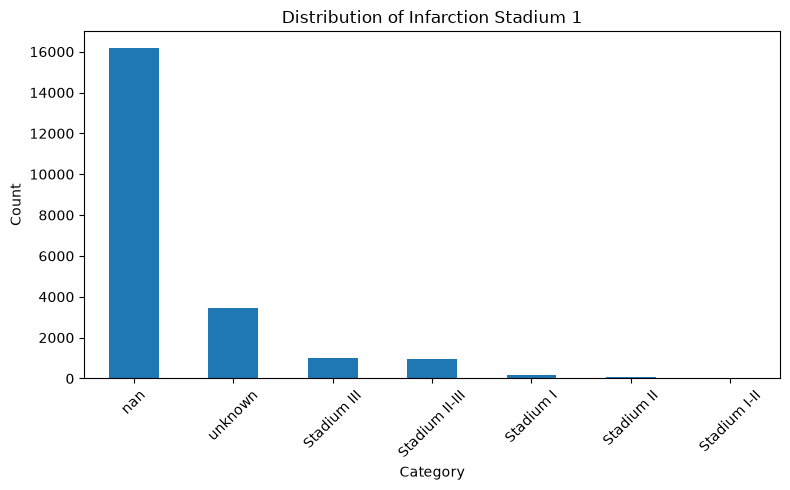

In [10]:
df['infarction_stadium1'].value_counts(dropna=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Distribution of Infarction Stadium 1")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Observation

The distribution of `infarction_stadium1` is highly concentrated in the missing and `"unknown"` categories.

Most records do not contain a specific infarction stage. Among the explicitly recorded stages, `Stadium III` and `Stadium II-III` are the most frequent categories, while `Stadium I-II` is extremely rare.

This indicates that `infarction_stadium1` provides specific infarction-stage information for only a small portion of the dataset and is highly incomplete overall.

However, the variable should not be removed solely based on this observation. Its usefulness will depend on the modeling objective and whether the information overlaps with the target labels.

### 3.6 Distribution of Infarction Stadium 2

We now examine `infarction_stadium2` to determine how frequently information is recorded in this variable and whether its distribution differs from `infarction_stadium1`.

This comparison will help us understand whether the second infarction-stage field contains meaningful additional information or is largely incomplete.

In [11]:
df['infarction_stadium2'].value_counts(dropna=False)

infarction_stadium2
NaN            21696
Stadium III       65
Stadium I         19
Stadium II        19
Name: count, dtype: int64

### Observation

The `infarction_stadium2` variable is extremely sparse. Out of 21,799 ECG recordings, 21,696 records have missing values, while only 103 records contain an explicitly recorded infarction stage.

Among the recorded values, `Stadium III` is the most frequent category, followed by `Stadium I` and `Stadium II`.

Compared with `infarction_stadium1`, the second infarction-stage variable contains substantially less information and is available for less than 1% of the observations.

This indicates that `infarction_stadium2` is an optional and highly sparsely populated annotation in this dataset. Its usefulness and handling will need to be evaluated later based on the modeling objective.

## 3.7 Investigating ECG Annotation Missingness

Several variables related to ECG signal quality and abnormalities have very high levels of missing data, including `baseline_drift`, `static_noise`, `burst_noise`, `electrodes_problems`, `extra_beats`, and `pacemaker`.

Before deciding how to handle these missing values, we need to understand what a missing value represents.

A missing annotation may indicate that the condition was not observed, that the annotation was not performed, or simply that the information was not recorded.

Therefore, we inspect the available values in these variables to understand their meaning and determine whether missingness itself carries information.

In [12]:
df["pacemaker"].value_counts(dropna=False)

pacemaker
NaN              21508
ja, pacemaker      285
ja, nan              3
PACE????, nan        2
?, nan               1
Name: count, dtype: int64

### Observation

The `pacemaker` variable is highly sparse, with approximately 98.67% of the observations containing missing values.

The available annotations are not represented as a clean binary variable. Instead, the column contains text-based values such as `"ja, pacemaker"`, `"ja, nan"`, `"PACE????, nan"`, and `"?, nan"`.

The presence of multiple inconsistent annotation formats indicates that the variable may require additional interpretation and cleaning if it is used as a feature.

Importantly, a missing value cannot automatically be interpreted as the absence of a pacemaker because the missingness may indicate that the annotation was not recorded rather than that the condition was absent.

Therefore, the meaning of missing values in this variable needs to be established before performing any imputation or transformation.

### 3.8 Unique Pacemaker Annotations

We inspect the unique non-missing annotations in the `pacemaker` variable to determine the level of variation and identify inconsistent or ambiguous entries.

In [13]:
df['pacemaker'].dropna().unique()

array(['ja, pacemaker', 'PACE????, nan', 'ja, nan', '?, nan'],
      dtype=object)

### Observation

The non-missing values of `pacemaker` contain only a small number of unique annotations, but the annotations are semi-structured and inconsistent.

The value `"ja, pacemaker"` appears to provide a clear pacemaker annotation, whereas values such as `"PACE????, nan"` and `"?, nan"` contain uncertainty. The presence of `"nan"` within some string values also indicates that missing information can exist inside the annotation itself.

Therefore, the `pacemaker` variable is not currently represented as a clean binary or categorical feature. If this variable is used later, its annotations will need to be interpreted and standardized carefully.

At this stage, no imputation or recoding is performed because the semantic meaning of the missing and ambiguous values has not yet been established.

### 3.9 Investigating Baseline Drift

`baseline_drift` is an ECG signal-quality annotation that indicates the presence of baseline drift artifacts in the ECG signal.

We examine its value distribution to determine how frequently the annotation is present and how the available annotations are represented.

In [14]:
df['baseline_drift'].value_counts(dropna=False).head(15)

baseline_drift
NaN              20201
 , V6              221
 , V1               94
 , II-AVF           60
 , V3               59
 , V2               58
 , V5,V6            57
 , alles            55
 , I-AVF            47
 , V5               46
 , v6               44
 , V4               35
 , II,III,AVF       23
 , III,AVF          22
 , I,III,AVL        22
Name: count, dtype: int64

### Observation

The `baseline_drift` variable contains a very high proportion of missing values, with approximately 92.67% of the observations having no recorded annotation.

The available values are not simple categorical labels. Instead, they contain ECG lead identifiers such as `V1`, `V2`, `V6`, `II-AVF`, and combinations of multiple leads such as `V5,V6`.

This indicates that `baseline_drift` is a lead-level ECG signal-quality annotation rather than a conventional categorical variable. The values appear to identify the leads affected by baseline drift.

Therefore, treating each unique string as an independent category may not be appropriate. If this variable is used later, it may need to be transformed into a more meaningful representation, such as lead-level indicators.

### 3.9.1 Inspecting Unique Baseline Drift Annotations

We inspect the unique non-missing annotations to determine whether the values consistently represent ECG leads or whether additional annotation formats are present.

In [15]:
df['baseline_drift'].dropna().unique()

array([' , II,III,AVF', ' , III,AVR,AVF', ' , V1', ' , II,AVF',
       ' , II-AVL,AVF', ' , V3', ' , III', ' , V6', ' , AVF',
       ' , II-AVF,V5,V6', ' , III,AVF', ' , II-AVF', ' , alles',
       ' , III,V3,V6', ' , I-AVR', ' , II-AVF,V5', ' , V5', ' , AVR',
       ' , V2', ' , II-V2', ' , V1V6', ' , II-V6', ' , V1 ', ' , AVL',
       ' , III,V4', ' , II,III,AVF-V6', ' , V5 ', ' , III,AVL', 'v5-6,  ',
       'v2,  ', ' , V1,2', ' , 1', ' , III,V1', ' , V4,V5',
       ' , III,V3-V6', ' , V1-V3', ' , V4', ' , III,V5,V6', 'V4,  ',
       ' , I-AVF,V5,V6', ' , V1,V6', ' , V4-V6', ' , V3,5,6',
       ' , I,II,AVR', ' , v4', ' , V5,V6', ' , II-V1', ' , I,III-V1',
       'v5,  ', ' , v6', ' , I-AVF', ' , v2', ' , v4-6', ' , v1-6',
       'v3,  ', 'v3, v1-6', ' , alle', ' , I,III,AVL,AVF', ' , I-AVL',
       ' , V1-V6', ' , III,AVF,V4', 'v6,  ', ' , v1', ' , v3, v6',
       ' , I-AVL,AVF', ' , I,II,AVR,V1', 'v3,6,  ', ' , II,III,AVL,AVF',
       'v2,3,  ', ' , V5,6', ' , 2', ' , V1,3,4,6', '

### Observation

The non-missing values of `baseline_drift` primarily contain ECG lead information, including individual leads, groups of leads, and combinations of leads.

However, the annotations are not completely standardized. The column contains different representations of lead combinations as well as special values such as `"all"` and `"drift"`. Therefore, the 317 unique values should not be interpreted as 317 independent categorical classes.

The variable appears to represent lead-level signal-quality information with a semi-structured format. If it is used during preprocessing, the annotations may need to be parsed into meaningful lead-level indicators rather than directly applying categorical encoding to the raw strings.

At this stage, no transformation is performed because the purpose of EDA is to understand the structure of the annotations before deciding how they should be processed.

### 3.10 Investigating Static Noise

`static_noise` is another ECG signal-quality annotation that may indicate the presence of static noise in specific ECG leads.

We examine its value distribution to understand the amount of missing information and the structure of the available annotations.

In [16]:
df['static_noise'].value_counts(dropna=False).head(15)

static_noise
NaN                           18539
 , I-AVR,                       953
 , I-AVF,                       919
 , alles,                       522
 , I-V1,                        156
 , I-V2,                        144
 , I-AVL,                        91
 , mittel,                       70
 , leicht,                       42
 , stark,                        25
 , I,II,                         25
 , noisy recording,              21
 , alles, noisy recording,       17
leicht,  ,                       14
 , V1,                           13
Name: count, dtype: int64

### Observation

The `static_noise` variable contains approximately 85.05% missing values, with only 3,260 ECG recordings containing a non-missing annotation.

The available annotations contain different types of information. Some values identify affected ECG leads, such as `I-AVR`, `I-AVF`, `I-V1`, and `I-V2`, while other values describe the severity or nature of the noise, such as `leicht`, `mittel`, `stark`, and `noisy recording`.

The presence of values such as `alles` and combinations such as `alles, noisy recording` also indicates that the annotations can contain multiple pieces of information within a single string.

Therefore, `static_noise` is a semi-structured signal-quality annotation rather than a conventional categorical variable. Directly treating every unique string as a separate category may not preserve the underlying meaning of the annotations.

### 3.11 Investigating Burst Noise

`burst_noise` is another ECG signal-quality annotation. We examine its distribution to determine how frequently burst-noise annotations are recorded and what type of information is contained in the available values.

In [17]:
df['burst_noise'].value_counts(dropna=False).head(15)

burst_noise
NaN      21186
alles      140
I-AVF       47
V1          46
V1,V2       28
I-AVR       24
V2          22
I-V1        21
I-V2        20
v3          17
v6          15
V3          13
V5          13
V4          12
v5          11
Name: count, dtype: int64

### Observation

The `burst_noise` variable is extremely sparse, with approximately 97.19% of the observations containing missing values. Only 613 ECG recordings contain a non-missing burst-noise annotation.

The available annotations primarily identify the ECG leads affected by burst noise, including individual leads such as `V1`, `V2`, and `V3`, as well as combinations such as `V1,V2`. The value `alles` also appears, indicating an annotation involving all leads.

Similar to `baseline_drift`, the values represent lead-level signal-quality information rather than conventional categorical classes. Therefore, the raw string values should not automatically be treated as independent categories during preprocessing.

### 3.12 Investigating Electrode Problems

`electrodes_problems` records problems associated with ECG electrodes.

The variable has an extremely high missing rate, so we inspect the available annotations to determine whether the small number of recorded values contain meaningful and consistent information.

In [18]:
df['electrodes_problems'].value_counts(dropna=False)

electrodes_problems
NaN                         21769
V6                              8
V4                              5
V1                              4
V1???                           2
V5                              2
V3                              1
V5,V6                           1
Kontaktprobleme aVL ???         1
I???                            1
aVL???                          1
v6????                          1
Elektroden vertauscht???        1
v4, v5                          1
V3,V4-V6                        1
Name: count, dtype: int64

### Observation

The `electrodes_problems` variable is extremely sparse, with approximately 99.86% of the observations containing missing values. Only 30 out of 21,799 ECG recordings have a non-missing annotation.

The recorded values primarily identify affected ECG leads, such as `V6`, `V4`, `V1`, and combinations such as `V5,V6`. However, several annotations contain uncertainty markers such as `???`, while others contain descriptive text such as `"Kontaktprobleme"` and `"Elektroden vertauscht"`.

This indicates that `electrodes_problems` is a highly sparse, semi-structured annotation rather than a conventional categorical variable. The available values also contain inconsistent and uncertain annotations.

Because the number of annotated records is extremely small, the variable may have limited usefulness as a general predictive feature. However, this should be evaluated later rather than decided solely during the EDA stage.

### 3.13 Investigating Extra Beats

The `extra_beats` variable contains annotations related to additional or abnormal beats in the ECG recording.

Since the variable has a high proportion of missing values, we examine the available annotations to determine whether they represent specific ECG leads, beat types, or other forms of information.

In [19]:
df['extra_beats'].value_counts(dropna=False).head(15)

extra_beats
NaN           19850
1ES             405
SVES            381
2ES             179
VES             159
VES1,alles      151
3ES              80
VES2,alles       70
1,alles          61
ES               42
VES3,alles       40
4ES              29
VES,SVES         28
VES4,alles       20
2,alles          17
Name: count, dtype: int64

### Observation

The `extra_beats` variable contains approximately 91.06% missing values, with 19,850 out of 21,799 ECG recordings having no recorded annotation.

Unlike the previous signal-quality variables, the available values in this column primarily describe extra or ectopic beat annotations. Examples include `ES`, `SVES`, `VES`, `1ES`, `2ES`, and `3ES`, along with combinations such as `VES1,alles` and `VES2,alles`.

The annotations are semi-structured and contain different forms of information within the same field. Therefore, the raw values should not automatically be treated as independent categorical classes.

The variable appears to contain potentially meaningful ECG beat-related information, but its high missingness and semi-structured format mean that further interpretation and transformation would be required before using it as a model feature.

## 4. Demographic Variable Analysis

After examining missing and annotation-related variables, we now investigate the demographic characteristics of the ECG recordings.

The main demographic variables are:

- `age`
- `sex`
- `height`
- `weight`

We will examine their distributions, central tendencies, variability, and potential anomalous values.

This analysis helps us understand the characteristics of the population represented in the dataset and identify possible data-quality issues before preprocessing.

### 4.1 Statistical Summary of Demographic Variables

We first examine descriptive statistics for the demographic variables.

The summary includes measures such as the mean, standard deviation, minimum, quartiles, and maximum. These statistics help us understand the central tendency, spread, and potential extreme values in the demographic data.

In [20]:
demographic_cols = ["age", "sex", "height", "weight"]
df[demographic_cols].describe()

,age,sex,height,weight
count,21799.000000,21799.000000,6974.000000,9421.000000
mean,62.769301,0.479150,166.702323,70.995223
std,32.308813,0.499577,10.867321,15.878803
min,2.000000,0.000000,6.000000,5.000000
25%,50.000000,0.000000,160.000000,60.000000
50%,62.000000,0.000000,166.000000,70.000000
75%,72.000000,1.000000,174.000000,80.000000
max,300.000000,1.000000,209.000000,250.000000


### Observation

The demographic variables show that the typical recorded patient is approximately 62 years old, with a median age of 62 years. The median height is approximately 166 cm and the median weight is approximately 70 kg, assuming height and weight are recorded in centimeters and kilograms respectively.

The `sex` variable contains binary values (0 and 1), so its distribution should be examined using category frequencies rather than numerical statistics.

Several potentially anomalous values are also visible. The `age` variable has a maximum of 300 years, while `height` and `weight` have minimum values of 6 and 5 respectively. These values appear suspicious and require further investigation before any decision is made about treating them as invalid or outliers.

The demographic variables also have different levels of completeness, which will be considered separately during the missing-value analysis.

### 4.2 Investigating Potentially Anomalous Demographic Values

The descriptive statistics revealed several extreme values that may represent data-entry errors or unusual observations.

We investigate these observations directly to determine whether they are isolated values and whether they occur consistently across other patient variables.

In [21]:
df.loc[
    (df['age'] > 100) |
    (df['height'] < 100) |
    (df['weight'] < 20) |
    (df['height'] > 220) |
    (df['weight'] > 200),

    ["ecg_id", "patient_id", "age", "sex", "height", "weight"]
].sort_values('age', ascending = False)

,ecg_id,patient_id,age,sex,height,weight
21795,21834,20703.0,300.0,0,NaN,NaN
107,108,11810.0,300.0,1,NaN,57.0
247,255,4867.0,300.0,1,163.0,58.0
248,256,565.0,300.0,1,168.0,61.0
271,279,437.0,300.0,0,175.0,NaN
...,...,...,...,...,...,...
13908,13945,4587.0,5.0,0,97.0,17.0
14226,14263,3751.0,4.0,1,95.0,20.0
13634,13666,5548.0,4.0,1,140.0,15.0
9712,9736,1681.0,3.0,1,100.0,16.0


### Observation

The investigation identified 314 records containing at least one potentially unusual demographic value based on the initial thresholds.

The most notable issue is the presence of records with an age of 300 years, which is clearly inconsistent with a human patient's age and is likely to represent an invalid or incorrectly recorded value.

However, low height and weight values cannot automatically be classified as invalid. The dataset contains young patients, including records with ages between 2 and 5 years, for whom lower height and weight values may be physiologically plausible.

Therefore, demographic outliers should be evaluated in the context of other variables, particularly age, rather than being removed solely based on fixed thresholds.

### 4.3 Quantifying Potential Anomalies

The previous analysis combined multiple conditions into a single set of records. We now examine each condition separately to determine the extent of each potential anomaly.

This allows us to distinguish between clearly invalid values and values that may be plausible for specific age groups.

In [22]:
print("Age > 100:", (df["age"] > 100).sum())
print("Height < 100:", (df["height"] < 100).sum())
print("Weight < 20:", (df["weight"] < 20).sum())

Age > 100: 293
Height < 100: 13
Weight < 20: 9


### Observation

The dataset contains 293 records with age above 100 years, which are likely invalid values and require correction or removal during preprocessing.

Only 13 records have height below 100 and 9 records have weight below 20. These values should not automatically be considered invalid because the dataset contains young patients for whom lower height and weight values can be physiologically reasonable.

Therefore, age values above 100 require further attention, while height and weight anomalies should be interpreted together with patient age.

## 5. Patient-Level Analysis

A patient may have multiple ECG recordings. Understanding this relationship is important because patient-level duplication can cause data leakage when splitting the dataset for machine learning.

In [23]:
print("Unique patients:", df["patient_id"].nunique())
print("ECGs per patient:")
print(df["patient_id"].value_counts().describe())

Unique patients: 18869
ECGs per patient:
count    18869.000000
mean         1.155281
std          0.523105
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: count, dtype: float64


### Observation

The dataset contains 18,869 unique patients and 21,799 ECG recordings, indicating that some patients have multiple ECG recordings.

The average number of ECG recordings per patient is approximately 1.16. Most patients have only one recording, while some patients have multiple recordings, with a maximum of 10 ECGs for a single patient.

Therefore, patient identity should be considered when splitting the dataset to avoid the same patient's ECG recordings appearing across training and validation/test sets.

In [24]:
(df["patient_id"].value_counts() > 1).sum()

np.int64(2111)

### Observation

Out of 18,869 unique patients, 2,111 patients have more than one ECG recording.

Therefore, the dataset contains repeated ECG recordings from the same patients. A random row-level train-test split could place recordings from the same patient in different subsets, potentially causing patient-level data leakage.

The patient identifier should therefore be considered when designing the final train, validation, and test split.

## 6. Diagnostic Code Analysis

The `scp_codes` variable contains diagnostic annotations associated with each ECG recording.

Understanding these codes is important because they may be used to define the target labels for the machine learning model.

We will first inspect the structure and frequency of the diagnostic codes before deciding how the target should be constructed.

In [25]:
df['scp_codes'].head()

0    {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
1                {'NORM': 80.0, 'SBRAD': 0.0}
2                  {'NORM': 100.0, 'SR': 0.0}
3                  {'NORM': 100.0, 'SR': 0.0}
4                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, dtype: object

In [26]:
from ast import literal_eval
from collections import Counter

scp_counter = Counter()

for codes in df["scp_codes"]:
    scp_counter.update(literal_eval(codes).keys())

scp_counter.most_common(20)

[('SR', 16748),
 ('NORM', 9514),
 ('ABQRS', 3327),
 ('IMI', 2676),
 ('ASMI', 2357),
 ('LVH', 2132),
 ('NDT', 1825),
 ('LAFB', 1623),
 ('AFIB', 1514),
 ('ISC_', 1272),
 ('PVC', 1143),
 ('IRBBB', 1118),
 ('STD_', 1009),
 ('VCLVH', 875),
 ('STACH', 826),
 ('1AVB', 793),
 ('IVCD', 787),
 ('SARRH', 772),
 ('NST_', 767),
 ('ISCAL', 659)]

In [27]:
df["num_scp_codes"] = df["scp_codes"].apply(
    lambda x: len(literal_eval(x))
)

df["num_scp_codes"].describe()

count    21799.000000
mean         2.798615
std          1.211884
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          9.000000
Name: num_scp_codes, dtype: float64

### Observation

The `scp_codes` variable contains multiple diagnostic codes for individual ECG recordings, confirming that the diagnostic information is inherently multi-label.

The frequency analysis identifies the most common diagnostic codes and shows that ECGs may contain one or multiple diagnostic annotations.

Therefore, `scp_codes` is an important variable for defining the target labels and should not be treated as a conventional single categorical feature.

# 9. EDA Summary

The exploratory analysis provided the following key findings:

1. The dataset contains 21,799 ECG recordings across 28 variables.

2. There are 18,869 unique patients, and 2,111 patients have multiple ECG recordings. Therefore, patient-level splitting should be considered to avoid data leakage.

3. Missing values are highly concentrated in several optional ECG annotation variables. `electrodes_problems`, `infarction_stadium2`, `pacemaker`, `burst_noise`, `baseline_drift`, `extra_beats`, and `static_noise` contain very high levels of missingness.

4. Missing values do not necessarily represent the same meaning across variables. Some fields contain explicit `"unknown"` categories or semi-structured annotations, so missing-value treatment must be column-specific.

5. Several ECG annotation variables contain semi-structured information such as affected leads, noise characteristics, pacemaker information, and extra-beat annotations. Direct categorical encoding of their raw strings may not be appropriate.

6. The demographic variables show potential data-quality issues. In particular, 293 records have age values above 100, while low height and weight values may be valid for younger patients and should therefore be interpreted together with age.

7. The `scp_codes` variable contains multiple diagnostic codes per ECG, indicating that the diagnostic information is multi-label and is potentially important for defining the prediction target.

8. `ecg_id`, `patient_id`, and filename columns are identifiers or references rather than conventional predictive features.

9. `recording_date`, `device`, `site`, and other recording metadata provide additional contextual information that should be evaluated for usefulness and potential data leakage.

Overall, the dataset contains rich ECG, demographic, diagnostic, and recording metadata, but several variables require careful preprocessing because of missingness, semi-structured annotations, and potential patient-level or target leakage.

In [28]:
from ast import literal_eval
from collections import Counter

scp_counter = Counter()

for codes in df["scp_codes"]:
    scp_counter.update(literal_eval(codes).keys())

scp_counter.most_common(20)

[('SR', 16748),
 ('NORM', 9514),
 ('ABQRS', 3327),
 ('IMI', 2676),
 ('ASMI', 2357),
 ('LVH', 2132),
 ('NDT', 1825),
 ('LAFB', 1623),
 ('AFIB', 1514),
 ('ISC_', 1272),
 ('PVC', 1143),
 ('IRBBB', 1118),
 ('STD_', 1009),
 ('VCLVH', 875),
 ('STACH', 826),
 ('1AVB', 793),
 ('IVCD', 787),
 ('SARRH', 772),
 ('NST_', 767),
 ('ISCAL', 659)]

In [29]:
import pandas as pd

scp_df = pd.read_csv(
    "../data/raw/ptbxl/scp_statements.csv",
    index_col=0
)

scp_df[
    scp_df["description"]
    .str.contains(
        "infarction|myocardial|MI",
        case=False,
        na=False
    )
][
    ["description", "diagnostic", "diagnostic_class"]
]

,description,diagnostic,diagnostic_class
IMI,inferior myocardial infarction,1.0,MI
ASMI,anteroseptal myocardial infarction,1.0,MI
ISC_,non-specific ischemic,1.0,STTC
ISCAL,ischemic in anterolateral leads,1.0,STTC
ILMI,inferolateral myocardial infarction,1.0,MI
AMI,anterior myocardial infarction,1.0,MI
ALMI,anterolateral myocardial infarction,1.0,MI
ISCIN,ischemic in inferior leads,1.0,STTC
LMI,lateral myocardial infarction,1.0,MI
ISCIL,ischemic in inferolateral leads,1.0,STTC




The `scp_statements` table provides a mapping between individual SCP diagnostic codes and broader diagnostic classes.

For example, myocardial infarction codes such as `IMI`, `ASMI`, `AMI`, and `ALMI` are grouped under the `MI` diagnostic class, while ischemic codes such as `ISC_`, `ISCAL`, and `ISCIN` are grouped under `STTC`.

This mapping allows the individual SCP codes to be converted into clinically meaningful diagnostic classes rather than treating every SCP code as a separate target category.